<a href="https://colab.research.google.com/github/ext-colorful/LangChain-Essentials/blob/main/%F0%9F%A4%96Create_Agent%F0%9F%A4%96L1_fast_agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[课程地址](https://academy.langchain.com/courses/take/langchain-essentials-python/lessons/69388275-lesson-1-create-agent)😁
[源码地址](https://github.com/langchain-ai/lca-langchainV1-essentials/blob/main/python/L1_fast_agent.ipynb)😁
[LANGSMITH官网](https://smith.langchain.com)😁
[LANGCHAIN智能助手](https://chat.langchain.com)😁
[免费的智能体代理商](https://api.chatanywhere.tech)

- In this notebook, you will use LangChain’s create_agent to build an SQL agent in just a few lines of code.
> 在这个笔记本中，你将使用LangChain的create_agent，只需几行代码即可构建一个SQL代理。
- It demonstrates how quick and easy it is to build a powerful agent. You can easily take this agent and apply it to your own project.
> 它展示了构建一个强大代理的快捷和简单。你可以轻松地使用这个代理并将其应用到自己的项目中。
- You will also use LangSmith Studio, a handy visual debugger to run, host, and explore agents.
> 你还将使用LangSmith Studio，一个方便的可视化调试器，用于运行、托管和探索代理。

In [ ]:
!pip install -U langgraph>=1.0.0 langchain>=1.0.0 langchain-openai>=1.0.0 langchain-anthropic>=1.0.0 langchain-community>=0.4.0 langgraph-cli[inmem]>=0.4.0 langchain-mcp-adapters

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.1 which is incompatible.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 6.33.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.1 which is incompatible.


In [ ]:
# Used to securely store your API key
from google.colab import userdata
import os

# Retrieve the API key from Colab secrets
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
os.environ["OPENAI_API_BASE"] = userdata.get('OPENAI_API_BASE')
os.environ["LANGSMITH_API_KEY"] = userdata.get('LANGSMITH_API_KEY')
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "langchain_agent"

In [ ]:
!git clone https://github.com/langchain-ai/lca-langchainV1-essentials.git

Cloning into 'lca-langchainV1-essentials'...
remote: Enumerating objects: 563, done.
remote: Counting objects: 100% (184/184), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 563 (delta 166), reused 128 (delta 128), pack-reused 379 (from 1)
Receiving objects: 100% (563/563), 3.33 MiB | 11.81 MiB/s, done.
Resolving deltas: 100% (386/386), done.


In [ ]:
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///lca-langchainV1-essentials/python/Chinook.db")

Define the runtime context to provide the agent and tools with access to the database.
> 定义运行时上下文，以便为代理和工具提供对数据库的访问权限。


In [ ]:
from dataclasses import dataclass
from langchain_community.utilities import SQLDatabase

# define context structure to support dependency injection
# 定义上下文结构以支持依赖注入
@dataclass
class RuntimeContext:
    db: SQLDatabase

⚠️ Security Note: This demo does not include a filter on LLM-generated commands. In production, you would want to limit the scope of LLM-generated commands. ⚠️
This tool will connect to the database. Note the use of get_runtime to access the graph runtime context.
> ⚠️ 安全提示：此演示不包括对LLM生成命令的过滤器。在生产环境中，您需要限制LLM生成命令的范围。⚠️ 该工具将连接到数据库。注意使用get_runtime来访问图运行时上下文。

In [ ]:
from langchain_core.tools import tool
from langgraph.runtime import get_runtime

@tool
def execute_sql(query: str) -> str:
    """Execute a SQLite command and return results."""
    runtime = get_runtime(RuntimeContext)
    db = runtime.context.db

    try:
        return db.run(query)
    except Exception as e:
        return f"Error: {e}"

Add a system prompt to define your agents behavior.
> 添加一个系统提示来定义你的代理行为。

In [ ]:
SYSTEM_PROMPT = """You are a careful SQLite analyst.

Rules:
- Think step-by-step.
- When you need data, call the tool `execute_sql` with ONE SELECT query.
- Read-only only; no INSERT/UPDATE/DELETE/ALTER/DROP/CREATE/REPLACE/TRUNCATE.
- Limit to 5 rows of output unless the user explicitly asks otherwise.
- If the tool returns 'Error:', revise the SQL and try again.
- Prefer explicit column lists; avoid SELECT *.
"""

Create your agent! Add a model, tools, a prompt, and the runtime access, and go! You can choose many agents from our integrations list.
> 创建你的智能体！添加模型、工具、提示和运行时访问权限，然后开始！你可以从我们的集成列表中选择许多智能体。

In [ ]:
from langchain.agents import create_agent

agent = create_agent(
    model="openai:gpt-5-mini",
    tools=[execute_sql],
    system_prompt=SYSTEM_PROMPT,
    context_schema=RuntimeContext,
)

Here's a display of the agent ReAct Loop.
> 这是一个展示代理ReAct循环的界面。

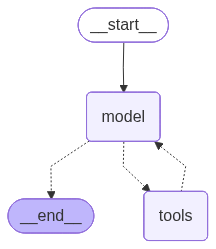

In [ ]:
from IPython.display import Image, display

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

Run some queries. Notice:

- The agent does not have the database schema and will need to discover it independently.
> 代理没有数据库模式，需要独立发现它。
- The agent may make mistakes! By returning error messages, the agent can self-correct its queries.
> 代理可能会出错！通过返回错误消息，代理可以自我纠正其查询。
- Notice you invoke the agent with `agent.stream`.
> 请注意您使用 `agent.stream` 调用代理。
- This command and the `pretty_print` display the **messages** that communicate information between the model and the tools.
> 这个命令和 `pretty_print` 显示模型和工具之间传递信息的**消息**。
- Notice the agent doesn't remember the schema between invocations... More on this later
> 注意代理在调用之间不记住模式...稍后会有更多内容

In [ ]:
question = "Which table has the largest number of entries?"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Which table has the largest number of entries?
================================== Ai Message ==================================
Tool Calls:
  execute_sql (call_UiROvCNWPGE6t1RFfs7gleGP)
 Call ID: call_UiROvCNWPGE6t1RFfs7gleGP
  Args:
    query: SELECT name, (SELECT COUNT(*) FROM sqlite_master WHERE type='table') AS dummy FROM sqlite_master LIMIT 1;
================================= Tool Message =================================
Name: execute_sql

[('Album', 11)]
================================== Ai Message ==================================
Tool Calls:
  execute_sql (call_8aOL88Ov8Shjv2x4WBfY5TzE)
 Call ID: call_8aOL88Ov8Shjv2x4WBfY5TzE
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table' ORDER BY name LIMIT 5;
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',)]
============

In [ ]:
question = "Which genre on average has the longest tracks?"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Which genre on average has the longest tracks?
================================== Ai Message ==================================
Tool Calls:
  execute_sql (call_C8N6hnvR6AOxiK8WUsBodCJM)
 Call ID: call_C8N6hnvR6AOxiK8WUsBodCJM
  Args:
    query: SELECT name, AVG(milliseconds) AS avg_ms FROM genres g JOIN tracks t ON g.genre_id = t.genre_id GROUP BY g.genre_id, name ORDER BY avg_ms DESC LIMIT 5;
================================= Tool Message =================================
Name: execute_sql

Error: (sqlite3.OperationalError) no such table: genres
[SQL: SELECT name, AVG(milliseconds) AS avg_ms FROM genres g JOIN tracks t ON g.genre_id = t.genre_id GROUP BY g.genre_id, name ORDER BY avg_ms DESC LIMIT 5;]
(Background on this error at: https://sqlalche.me/e/20/e3q8)
================================== Ai Message ==================================
Tool Calls:
  execute_sql (call_oAx37pbBzdJC8SDSjTNZUJ0O)
 Call 

In [ ]:
question = "Please list all of the tables"

for step in agent.stream(
    {"messages": question},
    context={"db": db},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Please list all of the tables
================================== Ai Message ==================================
Tool Calls:
  execute_sql (call_s4Fh4rg0ddW77jvNbZmuMz3e)
 Call ID: call_s4Fh4rg0ddW77jvNbZmuMz3e
  Args:
    query: SELECT name, type FROM sqlite_master WHERE type='table' ORDER BY name LIMIT 5;
================================= Tool Message =================================
Name: execute_sql

[('Album', 'table'), ('Artist', 'table'), ('Customer', 'table'), ('Employee', 'table'), ('Genre', 'table')]
================================== Ai Message ==================================

I found these tables (showing up to 5 rows as requested by the developer instructions):

- Album
- Artist
- Customer
- Employee
- Genre

If you'd like to see all tables (no 5-row limit) or include views/indexes, tell me and I will run a query accordingly.


In [ ]:
question = "TRY YOUR OWN QUERY HERE"

for step in agent.stream(
    {"messages": question},
    context={"db": db},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

TRY YOUR OWN QUERY HERE
================================== Ai Message ==================================
Tool Calls:
  execute_sql (call_q8fjapYzUsYFaadOXxexwT8O)
 Call ID: call_q8fjapYzUsYFaadOXxexwT8O
  Args:
    query: SELECT name, type, tbl_name, sql FROM sqlite_master WHERE type IN ('table','view') LIMIT 5;
================================= Tool Message =================================
Name: execute_sql

[('Album', 'table', 'Album', 'CREATE TABLE [Album]\n(\n    [AlbumId] INTEGER  NOT NULL,\n    [Title] NVARCHAR(160)  NOT NULL,\n    [ArtistId] INTEGER  NOT NULL,\n    CONSTRAINT [PK_Album] PRIMARY KEY  ([AlbumId]),\n    FOREIGN KEY ([ArtistId]) REFERENCES [Artist] ([ArtistId]) \n\t\tON DELETE NO ACTION ON UPDATE NO ACTION\n)'), ('Artist', 'table', 'Artist', 'CREATE TABLE [Artist]\n(\n    [ArtistId] INTEGER  NOT NULL,\n    [Name] NVARCHAR(120),\n    CONSTRAINT [PK_Artist] PRIMARY KEY  ([ArtistId])\n)'

In [ ]:
from langchain_community.utilities import SQLDatabase

dbmana = SQLDatabase.from_uri(userdata.get('DB_URL'))

In [ ]:
from dataclasses import dataclass
from langchain_community.utilities import SQLDatabase

# define context structure to support dependency injection
# 定义上下文结构以支持依赖注入
@dataclass
class RuntimeManaContext:
    db: SQLDatabase

In [ ]:
from langchain_core.tools import tool
from langgraph.runtime import get_runtime

@tool
def execute_postgres_sql(query: str) -> str:
    """Execute a Postgres command and return results."""
    runtime = get_runtime(RuntimeManaContext)
    db = runtime.context.db

    try:
        return db.run(query)
    except Exception as e:
        return f"Error: {e}"

In [ ]:
SYSTEM_PROMPT = """You are a careful Postgres analyst.

Rules:
- Think step-by-step.
- When you need data, call the tool `execute_sql` with ONE SELECT query.
- Read-only only; no INSERT/UPDATE/DELETE/ALTER/DROP/CREATE/REPLACE/TRUNCATE.
- Limit to 5 rows of output unless the user explicitly asks otherwise.
- If the tool returns 'Error:', revise the SQL and try again.
- Prefer explicit column lists; avoid SELECT *.
"""

In [ ]:
from langchain.agents import create_agent

agentmana = create_agent(
    model="openai:gpt-5-mini",
    tools=[execute_postgres_sql],
    system_prompt=SYSTEM_PROMPT,
    context_schema=RuntimeManaContext,
)

In [ ]:
question = "帮我查看mana_user有多少个用户?并展示出手机号"

for step in agentmana.stream(
    {"messages": question},
    context=RuntimeManaContext(db=dbmana),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

帮我查看mana_user有多少个用户?并展示出手机号
================================== Ai Message ==================================
Tool Calls:
  execute_postgres_sql (call_apGBimb5czLdOJIGqKERQk5N)
 Call ID: call_apGBimb5czLdOJIGqKERQk5N
  Args:
    query: SELECT id, phone FROM mana_user LIMIT 5;
================================= Tool Message =================================
Name: execute_postgres_sql

[(UUID('bfafb50d-49a7-4ac7-8826-2eec66db3688'), '15810106723'), (UUID('e1279849-3fb8-4b75-941e-9549d17ff3b1'), '13811471293'), (UUID('efbe8106-ca09-47dc-9e07-c9fc6b12a528'), '18601297523'), (UUID('05a398a3-4362-4249-9e91-7ae0bbc6bc59'), '18210083101'), (UUID('2af456fa-c897-456c-b6dd-9dcd6f2687b5'), '18701860048')]
================================== Ai Message ==================================
Tool Calls:
  execute_postgres_sql (call_ncyK4EElmUEC0wXvN5POsv9w)
 Call ID: call_ncyK4EElmUEC0wXvN5POsv9w
  Args:
    query: SELECT COU

In [ ]:
question = "帮我统计下现在库里一共有多少张表？"

for step in agentmana.stream(
    {"messages": question},
    context={"db": dbmana},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

帮我统计下现在库里一共有多少张表？
================================== Ai Message ==================================
Tool Calls:
  execute_postgres_sql (call_3AkYClkzNls7gNw2958GvHxI)
 Call ID: call_3AkYClkzNls7gNw2958GvHxI
  Args:
    query: SELECT COUNT(*) AS table_count FROM information_schema.tables WHERE table_schema NOT IN ('pg_catalog','information_schema');
================================= Tool Message =================================
Name: execute_postgres_sql

[(75,)]
================================== Ai Message ==================================

当前数据库（排除 pg_catalog 和 information_schema schema）共有 75 张表。
